# Music Recommendation Algorithm | Audio Clustering Project


## Objective

This project builds an **unsupervised content-based music recommendation system** 
using a real-world dataset of songs spanning 1950–2019 
(*Music Dataset: Lyrics and Metadata from 1950 to 2019*).

### Goal
Build an unsupervised music recommendation system that clusters songs by lyrical and thematic similarity using algorithms like KMeans, then maps user listening behavior to clusters to generate personalized song recommendations.

| EDA | Univariate, bivariate & multivariate analysis; hypothesis formulation |


In [12]:
#import important libraries 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns




In [13]:
#load the dataset
df = pd.read_csv('/Users/ingxrodriguez/Documents/Music_Recommendation_Algorithm/Dataset/Large_data.csv')

# Dataset Analisys 

The dataset contains **28,361 observations** and **24 columns**.

Each row represents one song, and each column represents information about the song, such as the artist name, track name, genre, release date, lyrical topic scores, lyric length, and song age. So there are **no missing values** in the dataset. 




In [21]:

#check df info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   artist_name               28362 non-null  object 
 2   track_name                28362 non-null  object 
 3   release_date              28362 non-null  int64  
 4   genre                     28362 non-null  object 
 5   lyrics                    28362 non-null  object 
 6   len                       28362 non-null  int64  
 7   dating                    28362 non-null  float64
 8   violence                  28362 non-null  float64
 9   world/life                28362 non-null  float64
 10  night/time                28362 non-null  float64
 11  shake the audience        28362 non-null  float64
 12  family/gospel             28362 non-null  float64
 13  romantic                  28362 non-null  float64
 14  commun

In [17]:
#check column names
print(df.columns)

Index(['Unnamed: 0', 'artist_name', 'track_name', 'release_date', 'genre',
       'lyrics', 'len', 'dating', 'violence', 'world/life', 'night/time',
       'shake the audience', 'family/gospel', 'romantic', 'communication',
       'obscene', 'music', 'movement/places', 'light/visual perceptions',
       'family/spiritual', 'sadness', 'feelings', 'topic', 'age'],
      dtype='object')


In [19]:
#datatypes of the columns
print(df.dtypes)

Unnamed: 0                    int64
artist_name                  object
track_name                   object
release_date                  int64
genre                        object
lyrics                       object
len                           int64
dating                      float64
violence                    float64
world/life                  float64
night/time                  float64
shake the audience          float64
family/gospel               float64
romantic                    float64
communication               float64
obscene                     float64
music                       float64
movement/places             float64
light/visual perceptions    float64
family/spiritual            float64
sadness                     float64
feelings                    float64
topic                        object
age                         float64
dtype: object


In [20]:
#Sample rows
print(df.head())

   Unnamed: 0           artist_name            track_name  release_date genre  \
0           0                mukesh  mohabbat bhi jhoothi          1950   pop   
1           4         frankie laine             i believe          1950   pop   
2           6           johnnie ray                   cry          1950   pop   
3          10           pérez prado              patricia          1950   pop   
4          12  giorgos papadopoulos    apopse eida oneiro          1950   pop   

                                              lyrics  len    dating  violence  \
0  hold time feel break feel untrue convince spea...   95  0.000598  0.063746   
1  believe drop rain fall grow believe darkest ni...   51  0.035537  0.096777   
2  sweetheart send letter goodbye secret feel bet...   24  0.002770  0.002770   
3  kiss lips want stroll charm mambo chacha merin...   54  0.048249  0.001548   
4  till darling till matter know till dream live ...   48  0.001350  0.001350   

   world/life  ...  commun

In [22]:
# Check missing values in each column
df.isnull().sum()

Unnamed: 0                  0
artist_name                 0
track_name                  0
release_date                0
genre                       0
lyrics                      0
len                         0
dating                      0
violence                    0
world/life                  0
night/time                  0
shake the audience          0
family/gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement/places             0
light/visual perceptions    0
family/spiritual            0
sadness                     0
feelings                    0
topic                       0
age                         0
dtype: int64

In [23]:
# Check total number of missing values
df.isnull().sum().sum()

np.int64(0)

In [24]:
# Display basic summary statistics for numerical columns
df.describe()

,Unnamed: 0,release_date,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age
count,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000
mean,42948.166878,1990.239652,73.030534,0.021110,0.118371,0.120984,0.057356,0.017418,0.017045,0.048676,0.076651,0.097185,0.060067,0.047417,0.049008,0.024155,0.129402,0.030995,0.425148
std,24747.811462,18.486997,41.831605,0.052366,0.178658,0.172216,0.111892,0.040658,0.041968,0.106071,0.109497,0.181314,0.123346,0.091559,0.089553,0.051032,0.181149,0.071656,0.264100
min,0.000000,1950.000000,1.000000,0.000291,0.000284,0.000291,0.000289,0.000284,0.000289,0.000284,0.000291,0.000289,0.000289,0.000284,0.000284,0.000284,0.000284,0.000289,0.014286
25%,20393.500000,1975.000000,42.000000,0.000923,0.001120,0.001170,0.001032,0.000993,0.000923,0.000975,0.001144,0.001053,0.000975,0.000993,0.000993,0.000957,0.001144,0.000993,0.185714
50%,45407.000000,1991.000000,63.000000,0.001462,0.002506,0.006579,0.001949,0.001595,0.001504,0.001754,0.002632,0.001815,0.001815,0.001645,0.001815,0.001645,0.005263,0.001754,0.414286
75%,64089.500000,2007.000000,93.000000,0.004049,0.192538,0.197854,0.065778,0.009989,0.004785,0.042304,0.132111,0.088799,0.055109,0.054373,0.064302,0.025515,0.235115,0.032617,0.642857
max,82451.000000,2019.000000,199.000000,0.647706,0.981781,0.962105,0.973684,0.497463,0.545303,0.940789,0.645829,0.992298,0.956938,0.638021,0.667782,0.618073,0.981424,0.958810,1.000000


## Histogram Interpretation

Most lyrical topic scores are heavily concentrated near 0, meaning most songs do not 
strongly belong to any single lyrical theme. Only a few songs score high on features 
like `violence`, `romantic`, or `family/gospel`.

The `len` variable is right-skewed. Most songs have short to medium lyric lengths, 
while a smaller number of songs have very long lyrics. This skew suggests a 
log transformation may be needed before modeling.

The `age` variable is more uniformly distributed compared to the lyrical scores, 
meaning the dataset has decent representation across different decades. Values 
closer to 1 represent older songs and values closer to 0 represent newer songs.

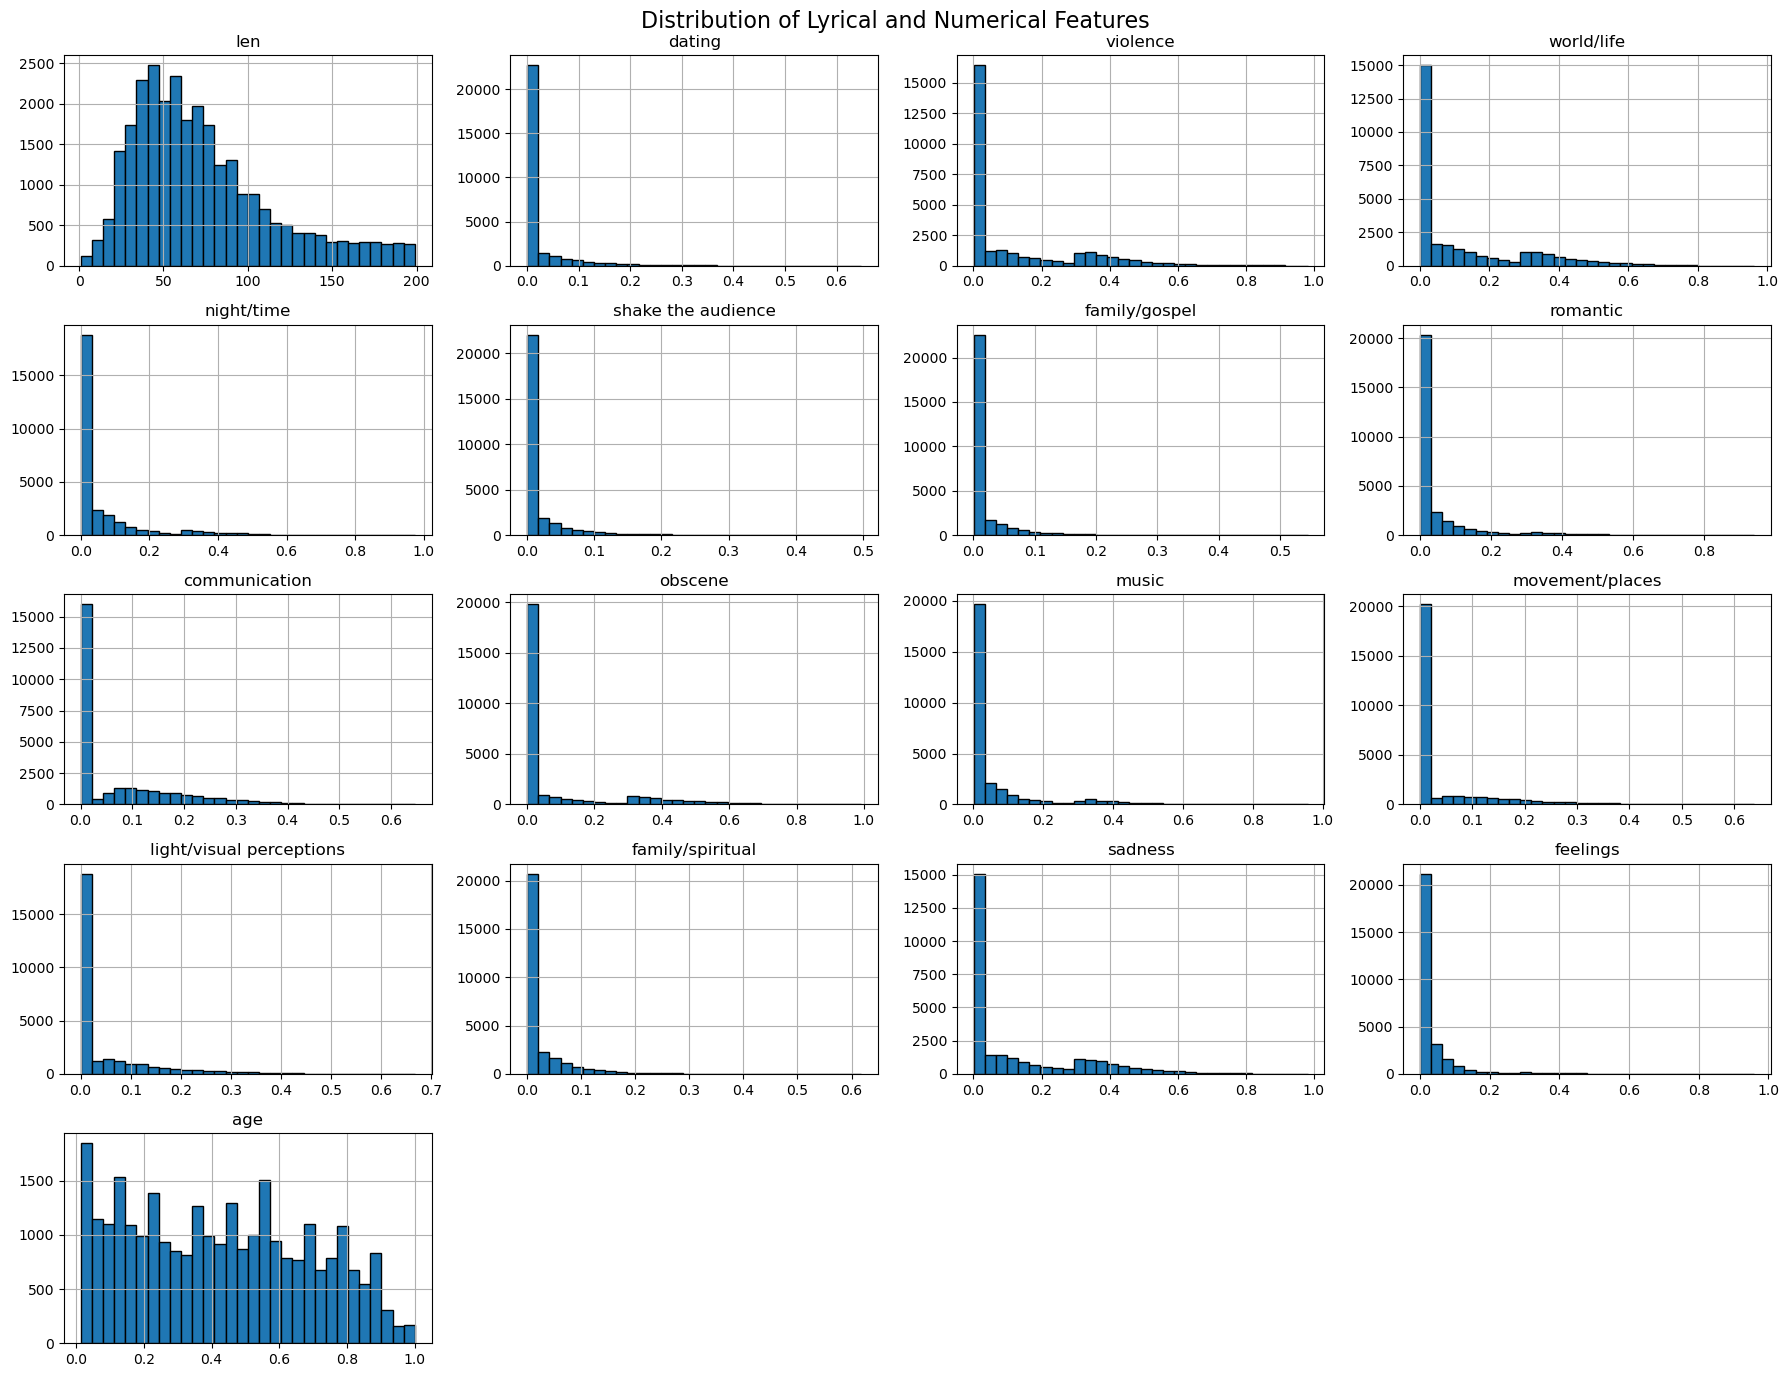

In [25]:
#create a histogram 

selected_numeric_cols = [
    "len", 
    "dating", 
    "violence", 
    "world/life", 
    "night/time", 
    "shake the audience",
    "family/gospel", 
    "romantic", 
    "communication", 
    "obscene", 
    "music", 
    "movement/places",
    "light/visual perceptions", 
    "family/spiritual", 
    "sadness", 
    "feelings", 
    "age"
]

df[selected_numeric_cols].hist(
    figsize=(18, 14),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Lyrical and Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

# Univariate Analysis

Let's explore categorical features, After analyzing the numerical columns, I explored the categorical columns `genre` and `topic`. This helps me understand how songs are distributed across music genres and lyrical topics. Since this is an unsupervised learning project, these variables can help me interpret the clusters later.

In [26]:
# Check unique values in genre and topic
print("Genres:")
print(df["genre"].unique())

print("\nTopics:")
print(df["topic"].unique())

Genres:
['pop' 'country' 'blues' 'jazz' 'reggae' 'rock' 'hip hop']

Topics:
['sadness' 'world/life' 'music' 'romantic' 'violence' 'obscene'
 'night/time' 'feelings']


In [27]:
# Count songs by genre
df["genre"].value_counts()

genre
pop        7038
country    5444
blues      4603
rock       4032
jazz       3844
reggae     2497
hip hop     904
Name: count, dtype: int64

In [28]:
# Count songs by topic
df["topic"].value_counts()

topic
sadness       6094
violence      5707
world/life    5419
obscene       4881
music         2303
night/time    1823
romantic      1523
feelings       612
Name: count, dtype: int64

# Insterpretation distribution  by genre and topic

The dataset is not evenly distributed across genres and topics. `Pop` is the most common genre, while `hip hop` is the least common genre. For lyrical topics, `sadness` is the most common topic, followed by `violence`, `world/life`, and `obscene`.

This is useful for the clustering project because the model may find groups of songs that reflect these dominant lyrical patterns. 


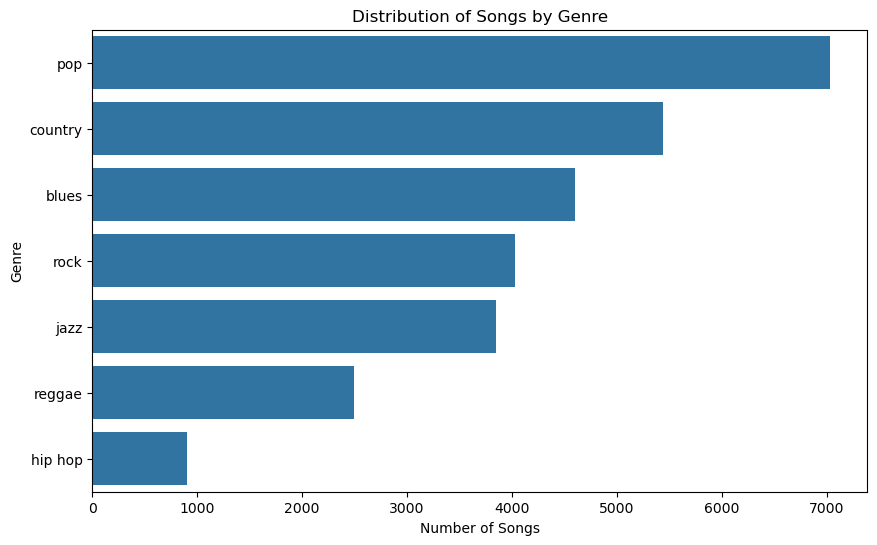

In [ ]:
# Visualize the distribution of songs by genre
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y="genre",
    order=df["genre"].value_counts().index
)

plt.title("Distribution of Songs by Genre")
plt.xlabel("Number of Songs")
plt.ylabel("Genre")
plt.show()

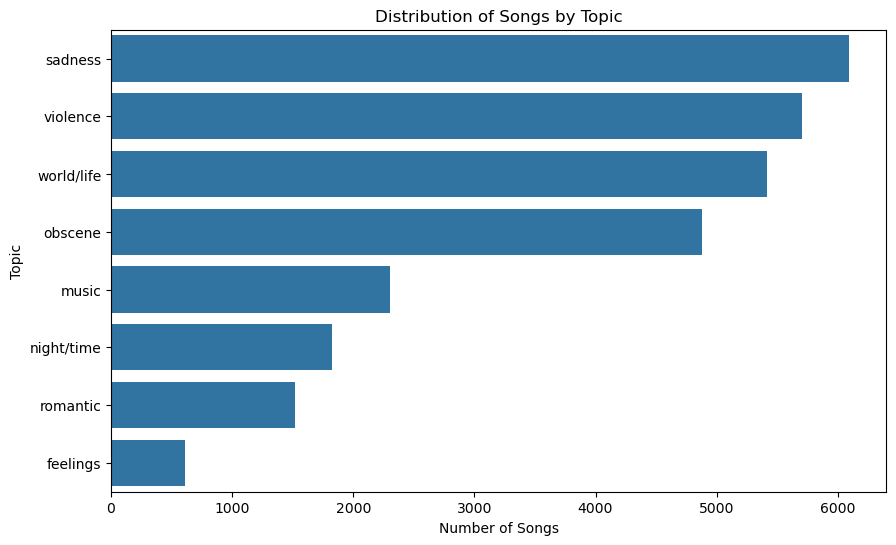

In [ ]:
# Visualize the distribution of songs by topic
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y="topic",
    order=df["topic"].value_counts().index
)

plt.title("Distribution of Songs by Topic")
plt.xlabel("Number of Songs")
plt.ylabel("Topic")
plt.show()

# Average score for each lyrical theme




The average lyrical theme scores show that `sadness`, `world/life`, `violence`, and `obscene` have the highest average scores in the dataset. this suggests that many songs contain stronger emotional, life-related, violent, or obscene/lifestyle lyrical content compared with other themes. themes such as `family/gospel`, `shake the audience`, and `dating` have lower average scores, meaning they are less dominant across the dataset. 


In [5]:
# Analyze the average values of lyrical themes
theme_cols = [
    "dating",
    "violence",
    "world/life",
    "night/time",
    "shake the audience",
    "family/gospel",
    "romantic",
    "communication",
    "obscene",
    "music",
    "movement/places",
    "light/visual perceptions",
    "family/spiritual",
    "sadness",
    "feelings"
]

theme_means = df[theme_cols].mean().sort_values(ascending=False)

theme_means

sadness                     0.129402
world/life                  0.120984
violence                    0.118371
obscene                     0.097185
communication               0.076651
music                       0.060067
night/time                  0.057356
light/visual perceptions    0.049008
romantic                    0.048676
movement/places             0.047417
feelings                    0.030995
family/spiritual            0.024155
dating                      0.021110
shake the audience          0.017418
family/gospel               0.017045
dtype: float64

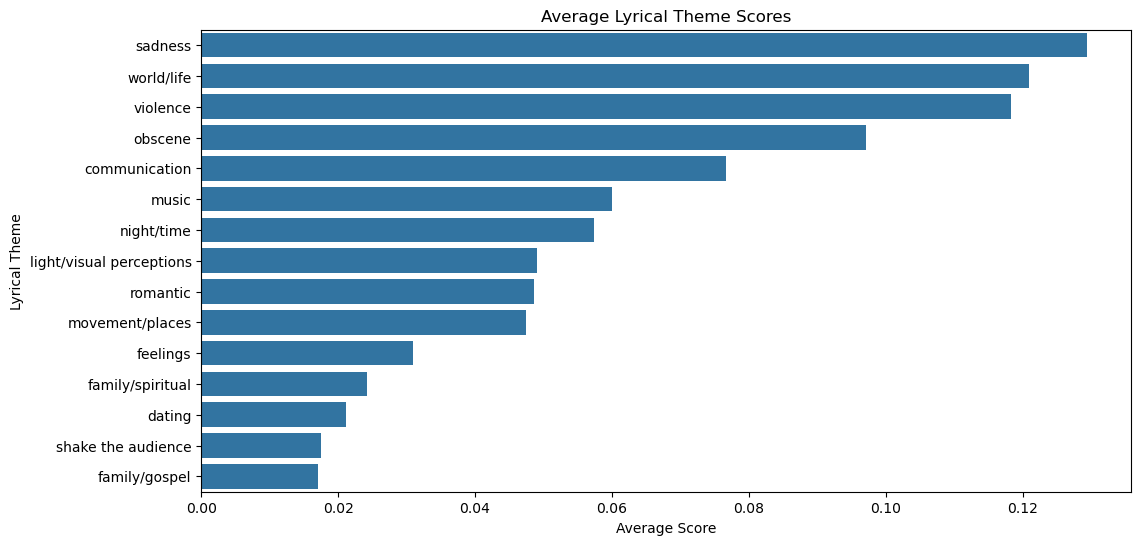

In [ ]:
# Visualize the average lyrical theme scores
plt.figure(figsize=(12, 6))

sns.barplot(
    x=theme_means.values,
    y=theme_means.index
)

plt.title("Average Lyrical Theme Scores")
plt.xlabel("Average Score")
plt.ylabel("Lyrical Theme")
plt.show()

# Bivariate Analysis

The correlation heatmap shows a strong correlation between `len` and `obscene` (0.44). 
The longer a song is, the more likely it is to score high on obscene or lifestyle-related 
content. This pattern is likely driven by hip hop tracks, which tend to be both verbose 
and explicit.

Some lyrical themes also show negative correlations. For example, `obscene` is negatively 
related to `sadness` and `world/life`, meaning songs with higher obscene scores tend to 
have lower sadness and world/life scores. Explicit songs and emotional songs tell very 
different stories.

The correlation between `len` and `age` is also negative, suggesting that newer songs 
tend to have longer lyrics than older songs. Music has simply gotten more wordy over time.

Overall no feature pair exceeds > 0.5 so there are no strongly correlated columns. 
I do not need to drop many numerical features based on statistical correlation alone. 
However `family/spiritual` and `feelings` will be dropped during preprocessing because 
they measure concepts already captured by `family/gospel`, `sadness` and `romantic`. 
No need to tell the algorithm the same thing twice.

In [ ]:
# Analyze correlations between numerical features
selected_numeric_cols = [
    "len", 
    "dating", 
    "violence", 
    "world/life", 
    "night/time", 
    "shake the audience",
    "family/gospel", 
    "romantic", 
    "communication", 
    "obscene", 
    "music", 
    "movement/places",
    "light/visual perceptions", 
    "family/spiritual", 
    "sadness", 
    "feelings", 
    "age"
]

corr_matrix = df[selected_numeric_cols].corr()

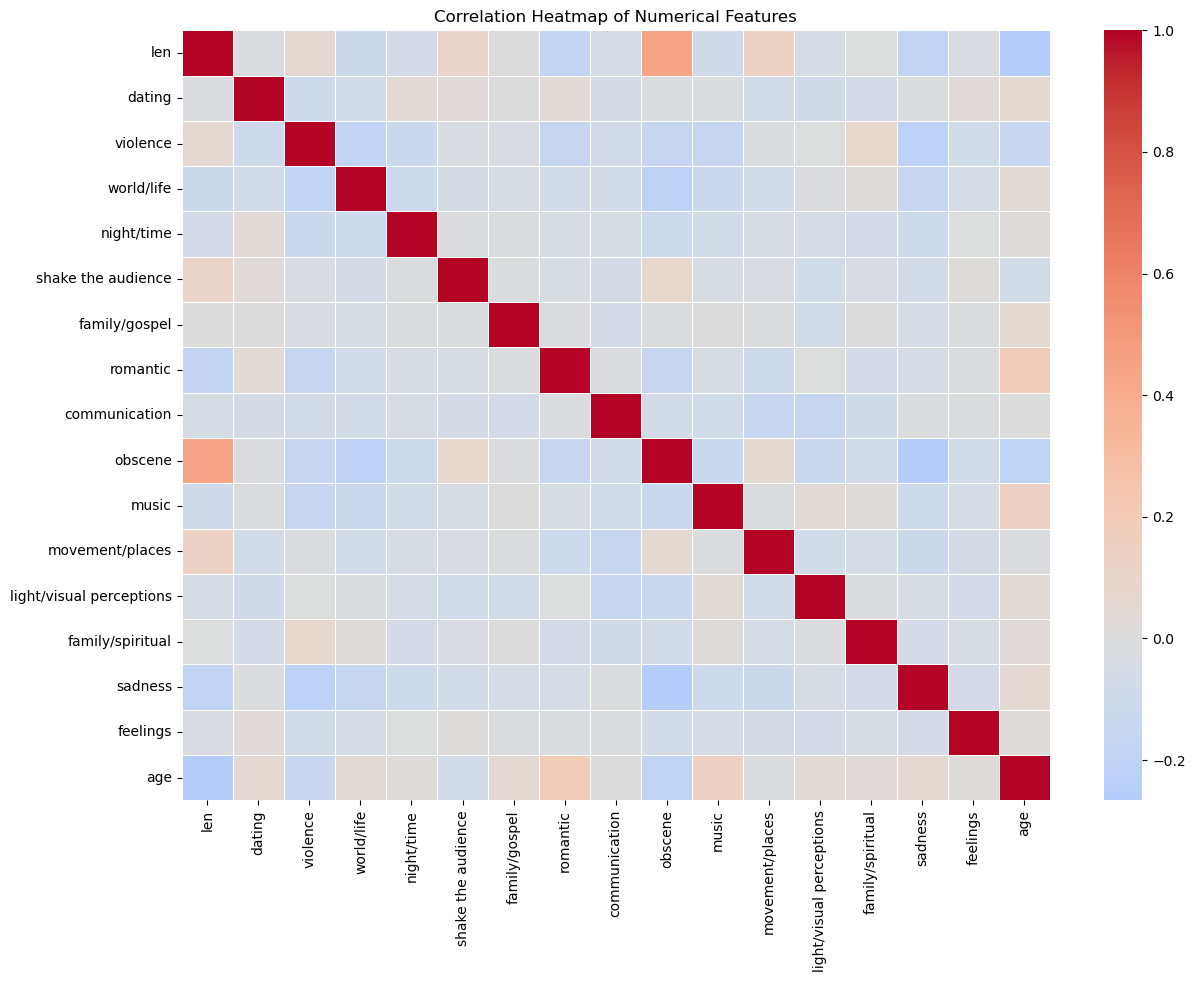

In [8]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [9]:
# Convert the correlation matrix into pairs
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs["Variable 1"] != corr_pairs["Variable 2"]]

# Remove duplicate pairs
corr_pairs["Pair"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["Variable 1"], row["Variable 2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("Pair")

# Add absolute correlation to find strongest relationships
corr_pairs["Abs Correlation"] = corr_pairs["Correlation"].abs()

# Select top 10 strongest correlations
top_corr = corr_pairs.sort_values("Abs Correlation", ascending=False).head(10)

top_corr

,Variable 1,Variable 2,Correlation,Pair,Abs Correlation
9,len,obscene,0.438449,"(len, obscene)",0.438449
167,obscene,sadness,-0.266126,"(obscene, sadness)",0.266126
16,len,age,-0.261223,"(age, len)",0.261223
48,violence,sadness,-0.221078,"(sadness, violence)",0.221078
60,world/life,obscene,-0.211483,"(obscene, world/life)",0.211483
169,obscene,age,-0.196165,"(age, obscene)",0.196165
14,len,sadness,-0.191908,"(len, sadness)",0.191908
135,romantic,age,0.191297,"(age, romantic)",0.191297
37,violence,world/life,-0.186943,"(violence, world/life)",0.186943
7,len,romantic,-0.175072,"(len, romantic)",0.175072


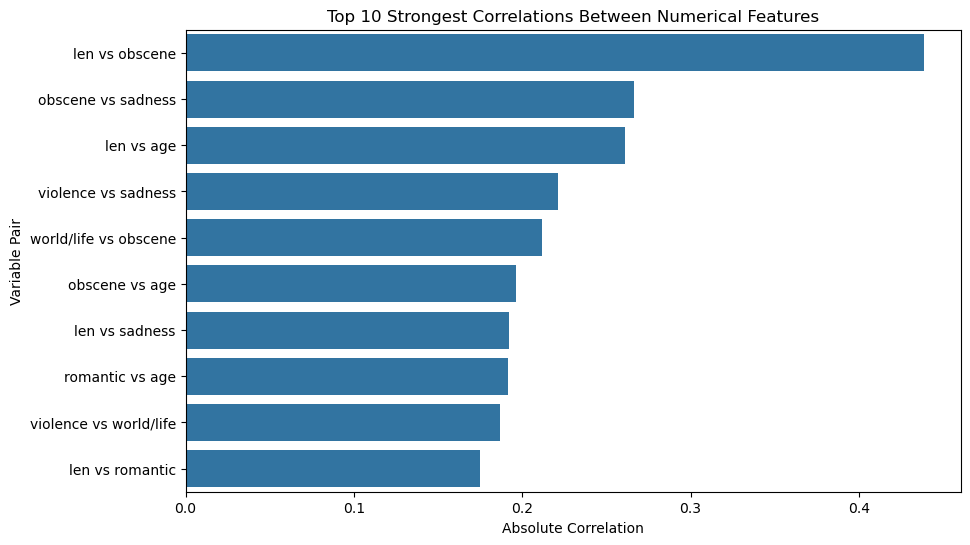

In [ ]:
#Let's visualize the top 10 strongest correlations
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_corr,
    x="Abs Correlation",
    y=top_corr["Variable 1"] + " vs " + top_corr["Variable 2"]
)

plt.title("Top 10 Strongest Correlations Between Numerical Features")
plt.xlabel("Absolute Correlation")
plt.ylabel("Variable Pair")
plt.show()

# Boxplot (genre vs obcene)
Hip hop songs score significantly higher on `obscene` compared to all other genres,
with a median score around 0.45. This suggests the clustering algorithm may naturally
form a distinct cluster driven by hip hop's explicit lyrical content. All other genres
cluster near 0, with reggae showing the most variability.

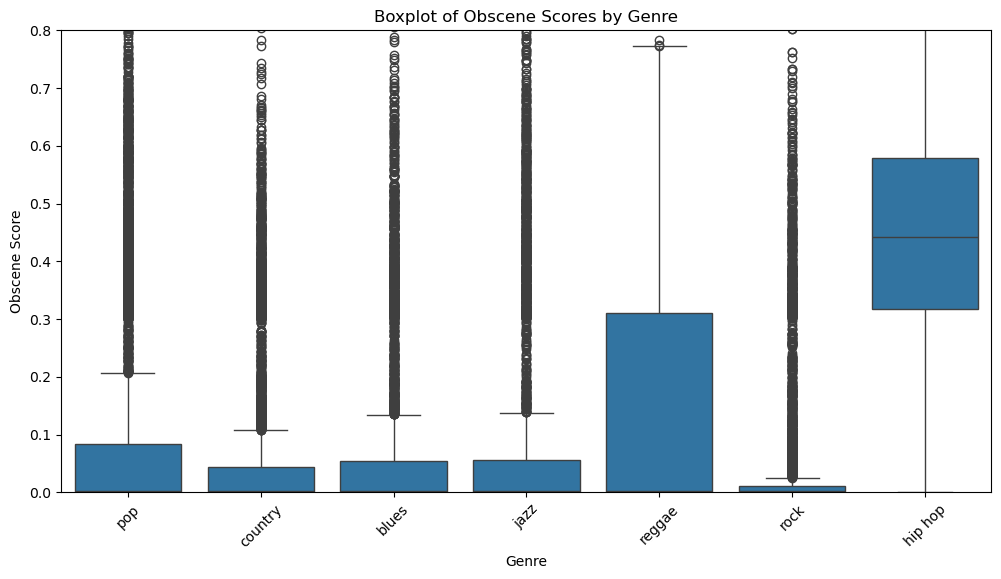

In [9]:
#Boxplot — genre vs a lyrical feature (e.g. genre vs obscene)
plt.figure(figsize=(12, 6)) 
sns.boxplot(
    data=df,
    x="genre",
    y="obscene"
)
plt.title("Boxplot of Obscene Scores by Genre")
plt.xlabel("Genre")
plt.ylabel("Obscene Score")
plt.ylim(0, 0.8)
plt.xticks(rotation=45)
plt.show()

# Boxplot (Genre and len)
Song length (`len`) is fairly consistent across genres, with most medians falling 
between 55 and 90 words. Reggae tends to have slightly longer songs, while country 
and blues are the most compact. Since `len` does not strongly differentiate genres 
on its own, it will need to work in combination with lyrical score features to 
contribute meaningfully to clustering.

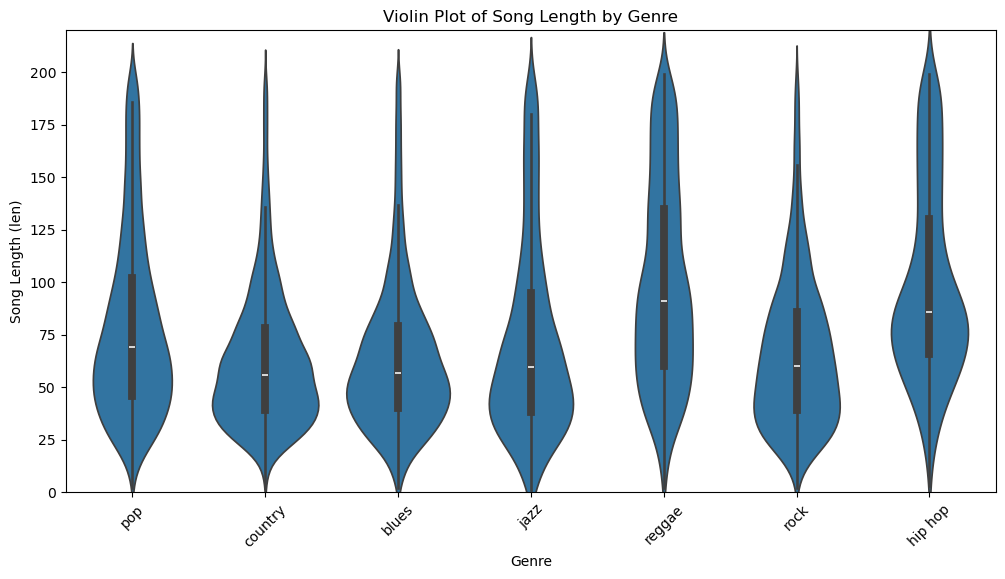

In [8]:
#Boxplot or violin — genre vs len
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df,
    x="genre",
    y="len"
)
plt.title("Violin Plot of Song Length by Genre")
plt.xlabel("Genre")
plt.ylabel("Song Length (len)")
plt.xticks(rotation=45)
plt.ylim(0, 220)
plt.show()

The scatter plot confirms the positive correlation between `len` and `obscene` (0.44). 
As song length increases, the likelihood of a higher obscene score also increases. 
However, the relationship is not perfectly linear — many long songs still score near 0, 
and some short songs score very high. This suggests that `len` is a contributing factor 
to explicit content, but not the only one. Genre likely plays a stronger role, 
as seen in the previous boxplot where hip hop dominated obscene scores.

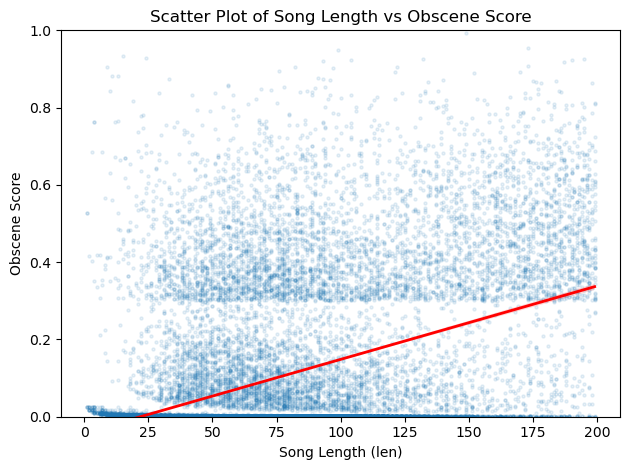

In [21]:
sns.regplot(data=df, x='len', y='obscene',
            scatter_kws={'alpha': 0.1, 's': 5},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Scatter Plot of Song Length vs Obscene Score')
plt.xlabel('Song Length (len)')
plt.ylabel('Obscene Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Bar Chart Average Lyrical Scores by Genre 

The bar chart shows the average lyrical scores across genres. The most notable finding 
is that **hip hop scores significantly higher on `obscene`** compared to all other genres, 
confirming the pattern seen in the boxplot. 

Country and gospel-adjacent genres score highest on `family/gospel`, while jazz and 
blues tend to lead on `night/time` themes. Romantic scores are relatively consistent 
across genres, with pop and country slightly ahead.

These differences suggest that **genre is a strong signal for clustering** — the 
algorithm is likely to separate hip hop from the rest based on its distinct lyrical profile.

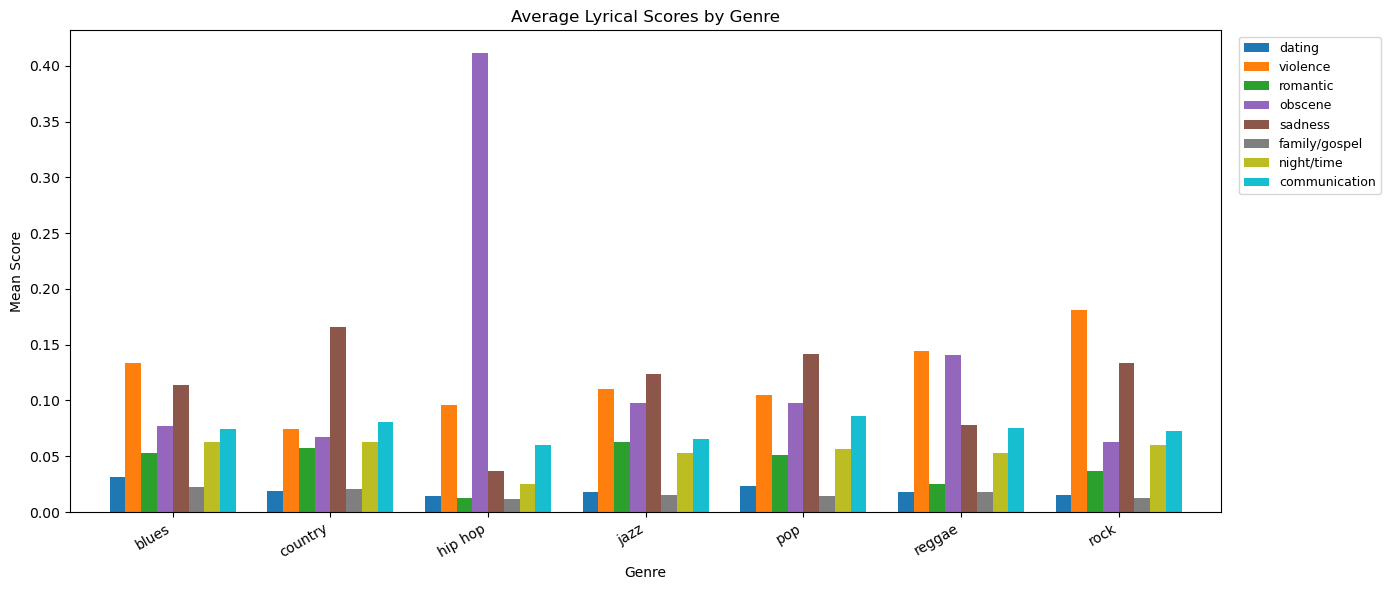

In [ ]:
#Bar Chart Average Lyrical Scores by Genre 
lyric_features = ['dating', 'violence', 'romantic', 'obscene', 
                  'sadness', 'family/gospel', 'night/time', 'communication']

genre_means = df.groupby('genre')[lyric_features].mean()

genre_means.plot(kind='bar', figsize=(14, 6), colormap='tab10', width=0.8)
plt.title('Average Lyrical Scores by Genre')
plt.xlabel('Genre')
plt.ylabel('Mean Score')
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Scatter: Age vs Obscene
The scatter plot shows a negative relationship between `age` and `obscene` score. 
Since `age = 1` represents the oldest songs and `age = 0` the newest, the downward 
red trend line confirms that **newer songs tend to score higher on obscene content**. 

This makes intuitive sense explicit lyrical content has become more common in 
modern music, particularly driven by the rise of hip hop since the 1990s. Older 
songs from the 1950s–1970s generally score near 0 on obscene content.

This finding suggests that `age` will be a useful feature in clustering, helping 
separate modern explicit songs from older, cleaner content.

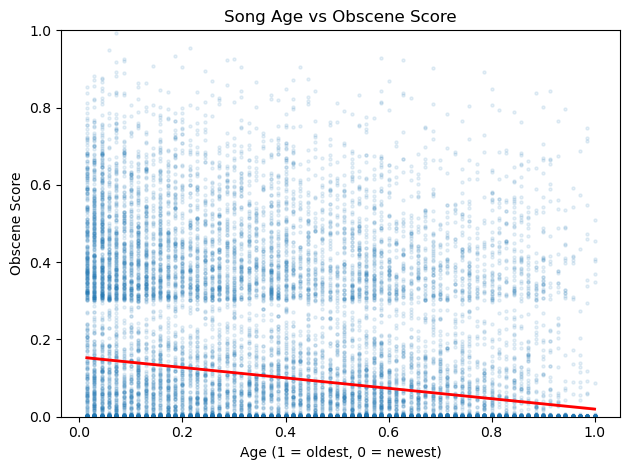

In [ ]:
# Scatter: Age vs Obscene
sns.regplot(data=df, x='age', y='obscene',
            scatter_kws={'alpha': 0.1, 's': 5},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Song Age vs Obscene Score')
plt.xlabel('Age (1 = oldest, 0 = newest)')
plt.ylabel('Obscene Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Multivariate analysis



**The pairplot** reveals that most genres overlap heavily across lyrical features. 
However, hip hop shows a distinctly wider distribution on `obscene`, separating 
itself from other genres. Rock shows a slight secondary peak on `violence`, and 
blues spreads further on `sadness`. 

Notably, high `obscene` and high `romantic` scores rarely co-occur, suggesting 
these themes are mutually exclusive in most songs. 

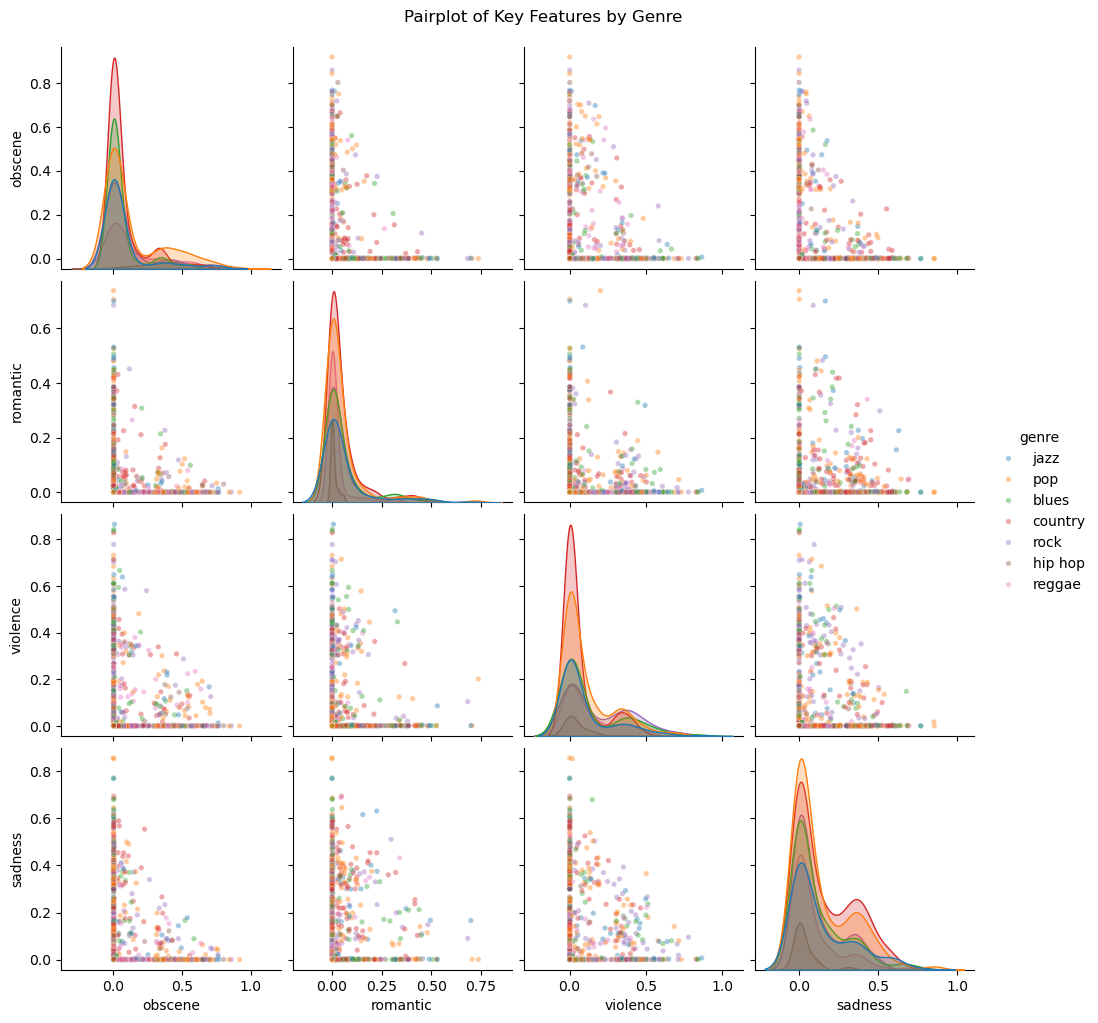

In [24]:
features = ['obscene', 'romantic', 'violence', 'sadness', 'genre']
sample = df[features].sample(1000, random_state=42)

sns.pairplot(sample, hue='genre', plot_kws={'alpha': 0.4, 's': 15},
             diag_kind='kde')
plt.suptitle('Pairplot of Key Features by Genre', y=1.02)
plt.show()

# The grouped boxplot
adds a time dimension to the genre analysis. Hip hop 
consistently scores the highest on `obscene` across all age groups, and only 
appears in newer time periods — confirming it as a modern, explicit-driven genre. 

Pop shows an interesting trend: newer pop songs score significantly higher on 
obscene than older ones, suggesting the genre has shifted toward more explicit 
content over time. Country, blues, and rock remain consistently low across all 
age groups, indicating these genres have maintained cleaner lyrical content 
regardless of era.

This three-way interaction between genre, age, and obscene content strongly 
suggests that both `genre` and `age` will be meaningful signals for clustering.

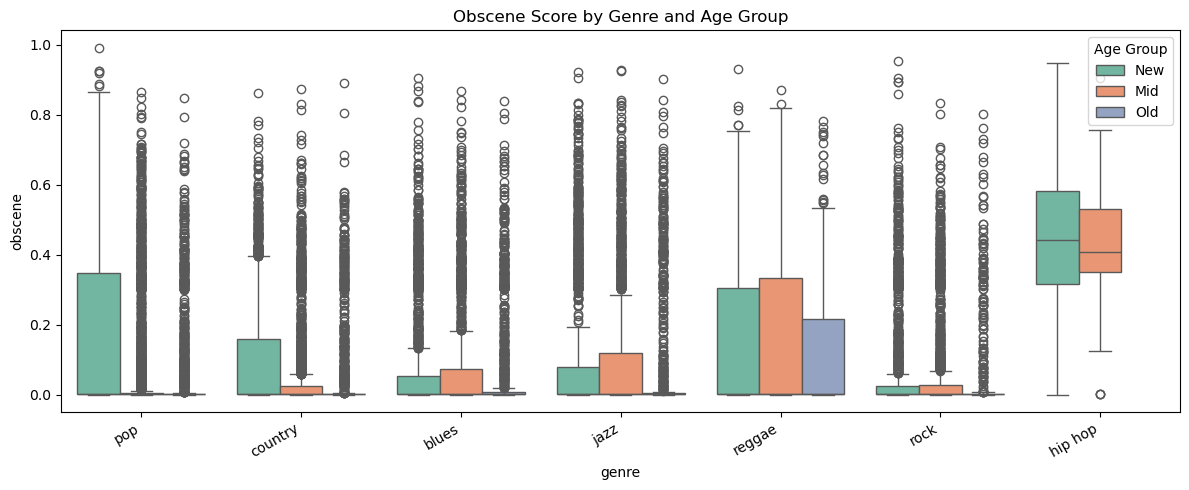

In [25]:
# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 0.33, 0.66, 1.0], 
                          labels=['New', 'Mid', 'Old'])

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='genre', y='obscene', hue='age_group', palette='Set2')
plt.title('Obscene Score by Genre and Age Group')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()

# Hypothesis

Observing the data, hip hop scores way higher on `obscene` than other genres 
and this pattern holds across all time periods. Meaning that modern songs in 
general tend to be more explicit than older ones, especially pop which has 
changed a lot over the decades.

I also noticed that features like `romantic`, `violence`, and `sadness` rarely 
overlap with each other songs tend to belong to one emotional theme, not many.

Based on that, I believe the algorithm will find groups based on lyrical mood. 
For example, if I am listening to Cigarettes After Sex, the clustering algorithm 
could recommend Lana Del Rey or Billie Eilish — because they share that same 
slow, melancholic, emotional feeling.

Genres do not define the clusters directly, but they will show up naturally 
inside them — hip hop in the explicit cluster, blues in the sad one, 
gospel in the spiritual one.